In [337]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

In [338]:
# lecture des données

df = pd.read_csv('student_habits_performance.csv')
df = pd.DataFrame(df)
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [339]:
# supprime la colonne "student_id"
df = df.drop('student_id', axis=1)
df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [340]:
# ... on décide de les remplacer par la valeur la plus fréquente
df['parental_education_level'] = df['parental_education_level'].fillna(df['parental_education_level'].mode()[0])

In [341]:
# remplace les données catégorielles par des donées numériques
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['part_time_job'] = le.fit_transform(df['part_time_job'])
df['diet_quality'] = le.fit_transform(df['diet_quality'])
df['parental_education_level'] = le.fit_transform(df['parental_education_level'])
df['internet_quality'] = le.fit_transform(df['internet_quality'])
df['extracurricular_participation'] = le.fit_transform(df['extracurricular_participation'])
df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,0,0.0,1.2,1.1,0,85.0,8.0,0,6,2,0,8,1,56.2
1,20,0,6.9,2.8,2.3,0,97.3,4.6,1,6,1,0,8,0,100.0
2,21,1,1.4,3.1,1.3,0,94.8,8.0,2,1,1,2,1,0,34.3
3,23,0,1.0,3.9,1.0,0,71.0,9.2,2,4,2,1,1,1,26.8
4,19,0,5.0,4.4,0.5,0,90.9,4.9,0,3,2,1,1,0,66.4


In [342]:
# place les données dans des numpy arrays X et y

data = np.array(df)
data = shuffle(data)

X = data[:,0:14].T
y = data[:,-1].reshape((1,1000))


In [343]:
def compute_grad(x,y,W2,W3,b2,b3):
    A1 = x

    Z2 = W2@A1 + b2
    A2 = sigma(Z2)

    Z3 = W3@A2 + b3
    A3 = Z3

    delta_3 = A3-y
    delta_2 = (np.transpose(W3)@delta_3)*sigma_prim(Z2)

    dC_W2 = (1/m)*delta_2@np.transpose(A1)
    dC_W3 = (1/m)*delta_3@np.transpose(A2)
    
    dC_b2 = (1/m)*np.sum(delta_2, axis=1).reshape((n2,1))
    dC_b3 = (1/m)*np.sum(delta_3, axis=1).reshape((1,1))
    
    return dC_W2, dC_W3, dC_b2, dC_b3

In [344]:
def featureNormalize(X):
    #to be completed
    X_min = np.min(X, axis=1, keepdims=True)
    X_max = np.max(X, axis=1, keepdims=True)
    X_norm = (X-X_min)/(X_max-X_min)

    return X_norm, X_min, X_max

In [345]:
m_train = 900

X_train = X[:, :m_train]
y_train = y[:, :m_train]

X_test = X[:, m_train:]
y_test = y[:, m_train:]

print("Taille X_train :", X_train.shape)
print("Taille Y_train :", y_train.shape)
print("Taille X_test :", X_test.shape)
print("Taille Y_test :", y_test.shape)

X_train_norm, X_min, X_max = featureNormalize(X_train)

X_test_norm = (X_test - X_min)/(X_max - X_min)

print("X_train norrm min", np.min(X_train_norm))
print("X_train norrm max", np.max(X_train_norm))


Taille X_train : (14, 900)
Taille Y_train : (1, 900)
Taille X_test : (14, 100)
Taille Y_test : (1, 100)
X_train norrm min 0.0
X_train norrm max 1.0


In [346]:
n2 = 20
alpha = 0.2
Niter = 800
m = 900

W2 = np.random.randn(n2,14)
b2 = np.random.randn(n2,1)

#avant
#W3 = np.random.randn(1,n2)
#b3 = np.random.randn(1)

W3 = np.random.randn(1, n2)
b3 = np.random.randn(1,1)

In [347]:
def sigma(z):
    return 1/(1+np.exp(-z))

In [348]:
def sigma_prim(z):
    # La dérivée de la sigmoïde s'exprime facilement à partir d'elle-même
    s = sigma(z)
    return s * (1 - s)

In [349]:
def cost(y, y_pred):
    # On récupère le vrai nombre d'exemples (m) dynamiquement
    m_actuel = y.shape[1] 
    # On utilise y_pred et non A3
    J = (1/m_actuel) * np.sum((y_pred - y)**2)
    return J

In [350]:
def model_predict(X, W2, W3, b2, b3):
    A1 = X
    Z2 = W2 @ A1 + b2
    A2 = sigma(Z2)
    Z3 = W3 @ A2 + b3
    A3 = Z3 # Retrait de la sigmoïde ici !
    
    return A3

Coût initial : 4646.5031423109
Coût final : 64.35361633178799


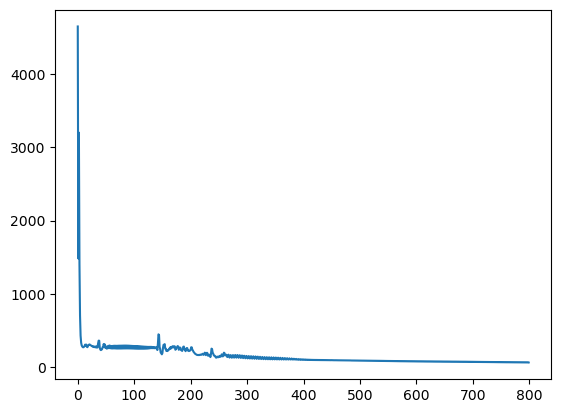

In [351]:
Cost = np.zeros(Niter)

for j in range(Niter):
    # 1. On prédit avec les données d'entraînement NORMALISÉES
    y_pred = model_predict(X_train_norm, W2, W3, b2, b3)
    
    # 2. On calcule le coût avec les vraies notes d'entraînement
    Cost[j] = cost(y_train, y_pred)
        
    # 3. On calcule le gradient (attention à bien passer X_train_norm et y_train)
    dC_dW2, dC_dW3, dC_db2, dC_db3 = compute_grad(X_train_norm, y_train, W2, W3, b2, b3)

    # 4. On met à jour les poids
    W2 = W2 - alpha * dC_dW2
    W3 = W3 - alpha * dC_dW3
    b2 = b2 - alpha * dC_db2
    b3 = b3 - alpha * dC_db3

# Un petit print pour voir si le coût a bien diminué
print("Coût initial :", Cost[0])
print("Coût final :", Cost[-1])

# Courbe de la fonction cout en fonction des itérations
plt.plot(Cost)